# Records Matching

DS 6105 | Summer 2026

**Know Their Names Capstone**

## Set Up

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import ipywidgets as widgets
from ipywidgets import interact
from IPython.display import display, HTML

## Read

### MENTION

We import the mentions data, dropping all the super-low entropy columns, i.e. where only one value exists, or they are all nulls.

In [2]:
mention_file = "../data/sources/all_mentions.csv"
mention_cols_to_drop = ['original_data','created','county','narrative','maiden_name','location_id','narrative_vector'] #'death_year','location_id','source_year','source'] 
MENTION = (
    pd.read_csv(mention_file, low_memory=False)
    .set_index('mention_id')
    .drop(mention_cols_to_drop, axis=1)
    # .drop_duplicates()
)

# Transform Key Cols 
MENTION.birth_year = MENTION.birth_year.fillna(-1).astype(int).astype(str).str.replace(r"-1", "XXXX")
MENTION.norm_race = MENTION.norm_race.fillna('X')
MENTION.gender = MENTION.gender.fillna('X')
MENTION.full_name = MENTION.full_name.fillna('X').str.upper()
MENTION['enslaver_name'] = MENTION.enslaver_id.map(MENTION.full_name).fillna('NA')

MENTION['person_key'] = MENTION.apply(lambda x: f"{x.birth_year}-{x.norm_race}-{x.gender}-{x.full_name}", axis=1)
MENTION.loc[~MENTION.enslaver_id.isna(), 'person_key'] = MENTION.person_key + "@" + MENTION.enslaver_name
MENTION.person_key = MENTION.person_key.str.replace(r" ", "_").str.lower()

In [3]:
MENTION.person_key.sample(10)

mention_id
f9654348-c1a7-4d79-9dfd-3bfbddd2bfa1       1879-w-f-cora_carpenter
2a1fc8e0-6713-4307-be49-b313b9904c8e          1873-b-f-bird_bailey
0cb12383-4dd6-4e8e-be18-422a9c770a0c        xxxx-b-f-mariah_howard
cf7cf64d-a864-44cc-b985-6a3dcb6f92c1        1830-b-m-x@wm_m_nelson
1e9a3a69-5af6-490a-a80e-ab0ecc31d88a               xxxx-x-f-hannah
807b3186-2566-4506-925b-ddadbd6beb00                    1859-b-m-x
4b56dd03-470a-4986-927d-3d123a482f21      1810-w-f-fannie_r_mcauly
42f4749f-07ca-48da-8aad-002b61088855    1860-b-m-paulus_richardson
5c4e85a2-41be-40ff-b3a8-330058f55177                xxxx-x-f-marie
79427f0b-a710-4a35-afb5-ddf395a59814      1832-b-f-x@clifton_brown
Name: person_key, dtype: str

In [4]:
MENTION.head()

,source,source_year,confidence,full_name,first_name,middle_name,last_name,birth_year,death_year,race,...,nysiis_last_name,norm_race,norm_occupation,enslaver_id,head,household_id,family_id,soundex_last_name,enslaver_name,person_key
mention_id,,,,,,,,,,,,,,,,,,,,,
8eb2af37-98df-4935-b526-cab4075c5964,ALB_CN_1870,1870,0.9,JESSIE THOMAS,Jessie,NaN,Thomas,1869,NaN,W,...,THOM,W,NaN,NaN,f,HC1870-1337,FC1870-626,T520,NA,1869-w-m-jessie_thomas
84328208-2bc5-4cbc-ac55-233bd7b113bd,ALB_CN_1870,1870,0.9,WILLIE G JOHNSON,Willie,G,Johnson,1862,NaN,W,...,JOHN,W,NaN,NaN,f,HC1870-1337,FC1870-626,J525,NA,1862-w-f-willie_g_johnson
d14cace6-7f1c-49f9-9fc1-e33f89017d13,ALB_CN_1870,1870,0.9,JOHN JOHNSON,John,NaN,Johnson,1843,NaN,W,...,JOHN,W,NaN,NaN,f,HC1870-1337,FC1870-626,J525,NA,1843-w-m-john_johnson
48ae47b9-4775-4df4-98b3-1deb30b57e79,ALB_CN_1870,1870,0.9,MARY K SWINGLER,Mary,K,Swingler,1817,NaN,B,...,SWIN,B,NaN,NaN,f,HC1870-1337,FC1870-636,S524,NA,1817-b-f-mary_k_swingler
67acea9d-19ad-47d6-a81b-486b0b384ec1,ALB_CN_1870,1870,0.9,CORNELIA SWINGLER,Cornelia,NaN,Swingler,1844,NaN,M,...,SWIN,B,NaN,NaN,f,HC1870-1337,FC1870-636,S524,NA,1844-b-f-cornelia_swingler


### ASSERTION

Next, we create an ASSERTION table that expands the keys using a double join to the MENTION table.

In [5]:
assertion_file = "../data/sources/all_assertions.csv"
assertion_cols_to_drop = ['created','object_string','county']
ASSERTION = (
    pd.read_csv(assertion_file, low_memory=False)
    .drop(assertion_cols_to_drop, axis=1)
    .merge(MENTION, left_on='subject_id', right_index=True)
    .merge(MENTION, left_on='object_id', right_index=True)
    # Alternate way of using .merge()
    # .merge(MENTION.reset_index(), left_on='subject_id', right_on='mention_id')
    # .merge(MENTION.reset_index(), left_on='object_id', right_on='mention_id')
)
# Fix spelling error in predicate names
ASSERTION.predicate = ASSERTION.predicate.str.replace(r"(Nibling|Pibling)", "Sibling", regex=True)
# Normalize predicate names
ASSERTION.predicate = ASSERTION.predicate.str.lower().str.replace(r"^(is|was)", "", regex=True).str.replace(r"(by|of)$", "_to", regex=True)
ASSERTION = ASSERTION.set_index(['predicate', 'subject_id','object_id'])
ASSERTION

assertion_id  \
predicate     subject_id                           object_id                                                                    
sibling_to    69525659-8037-4c6b-8e95-f9ea39de6a9c e130d4db-27d8-4292-9899-9f756dc38f55  dba4e056-8696-430c-a3ab-57c48fd1a990   
              e130d4db-27d8-4292-9899-9f756dc38f55 31beb3af-5912-4fde-be34-8b2eddb7e8be  209374c5-b915-400a-ac85-fef609ddbd9b   
spouse_to     31beb3af-5912-4fde-be34-8b2eddb7e8be e9011d45-259c-457c-9165-382813cbf8c7  e3b68404-51bd-485b-930c-88d6bd1db43f   
sibling_to    5109e136-9def-4b0b-bb15-e1e995bfc96b 771727e6-3f3a-4f70-8a91-bb59bfb23e32  2d879912-c1d2-4bf7-a350-8c3feee70729   
              e6a3466d-afed-473c-8794-b2c313968335 ae7ef57f-475f-4146-a9d6-9e25fd6149c4  801e0e28-4b8e-4c25-b6dd-225b0decca47   
...                                                                                                                       ...   
grandchild_to a058ee09-dea8-48af-a6a7-208b6ed262a0 3e4937a9-eef8-468d-940d-c3871e8ad30f  6b305ae5-14a3-42e9-bba4-09292c64c032   
              15618881-dc27-4381-a8cb-019e21adfd73 6cc6c6ff-9ac4-4680-8c5c-e0b89beb706e  1747e9c1-f87f-4d51-8c36-8c4f8ceb83ba   
              06f82ee9-13e2-4357-9d19-d3cb3ca3afe3 f0bbbb19-6ca4-4b3d-836d-3e772ed82d79  9f3b7eba-164e-4189-87fc-c57e7fc8267f   
              a0432e89-6ed8-437c-9079-10f3edce7f20 14bb3954-9023-45a5-8d38-848c197efc36  5cc91d11-826d-4a58-a89c-2bfe107a3aca   
              970df0c4-ed38-4d05-999e-ad1f91645ca3 94e6abaf-128f-4c48-908c-df0bbb820c35  1edc9db4-700e-4f89-bc7e-2b976793ce47   

                                                                                         start_year  \
predicate     subject_id                           object_id                                          
sibling_to    69525659-8037-4c6b-8e95-f9ea39de6a9c e130d4db-27d8-4292-9899-9f756dc38f55        1870   
              e130d4db-27d8-4292-9899-9f756dc38f55 31beb3af-5912-4fde-be34-8b2eddb7e8be        1870   
spouse_to     31beb3af-5912-4fde-be34-8b2eddb7e8be e9011d45-259c-457c-9165-382813cbf8c7        1870   
sibling_to    5109e136-9def-4b0b-bb15-e1e995bfc96b 771727e6-3f3a-4f70-8a91-bb59bfb23e32        1880   
              e6a3466d-afed-473c-8794-b2c313968335 ae7ef57f-475f-4146-a9d6-9e25fd6149c4        1870   
...                                                                                             ...   
grandchild_to a058ee09-dea8-48af-a6a7-208b6ed262a0 3e4937a9-eef8-468d-940d-c3871e8ad30f        1870   
              15618881-dc27-4381-a8cb-019e21adfd73 6cc6c6ff-9ac4-4680-8c5c-e0b89beb706e        1870   
              06f82ee9-13e2-4357-9d19-d3cb3ca3afe3 f0bbbb19-6ca4-4b3d-836d-3e772ed82d79        1870   
              a0432e89-6ed8-437c-9079-10f3edce7f20 14bb3954-9023-45a5-8d38-848c197efc36        1870   
              970df0c4-ed38-4d05-999e-ad1f91645ca3 94e6abaf-128f-4c48-908c-df0bbb820c35        1870   

                                                                                         end_year  \
predicate     subject_id                           object_id                                        
sibling_to    69525659-8037-4c6b-8e95-f9ea39de6a9c e130d4db-27d8-4292-9899-9f756dc38f55       NaN   
              e130d4db-27d8-4292-9899-9f756dc38f55 31beb3af-5912-4fde-be34-8b2eddb7e8be       NaN   
spouse_to     31beb3af-5912-4fde-be34-8b2eddb7e8be e9011d45-259c-457c-9165-382813cbf8c7       NaN   
sibling_to    5109e136-9def-4b0b-bb15-e1e995bfc96b 771727e6-3f3a-4f70-8a91-bb59bfb23e32       NaN   
              e6a3466d-afed-473c-8794-b2c313968335 ae7ef57f-475f-4146-a9d6-9e25fd6149c4       NaN   
...                                                                                           ...   
grandchild_to a058ee09-dea8-48af-a6a7-208b6ed262a0 3e4937a9-eef8-468d-940d-c3871e8ad30f       NaN   
              15618881-dc27-4381-a8cb-019e21adfd73 6cc6c6ff-9ac4-4680-8c5c-e0b89beb706e       NaN   
              06f82ee9-13e2-4357-9d19-d3cb3ca3afe3 f0bbbb19-6ca4-4b3d-836d-3e772ed82d

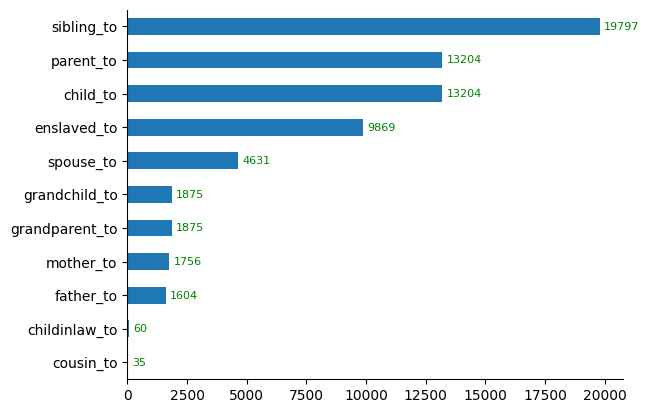

In [6]:
ax = ASSERTION.reset_index().predicate.value_counts().sort_values().plot.barh(logx=False)
ax.bar_label(ax.containers[0], fontsize=8, padding=3, color='green')
plt.ylabel("")
sns.despine()
plt.show()

## Transform

### MENTION $\rightarrow$ PERSON

Next, we extract unique person key strings from MENTION.

We alslo keep track of the number of times the string appears in the source data.

In [7]:
key_cols = ['birth_year', 'norm_race', 'gender', 'full_name', 'enslaver_name']

In [8]:
# MENTION.value_counts(key_cols).shape[0] - MENTION.person_key.value_counts().shape[0]

In [9]:
PERSON = MENTION.value_counts(key_cols + ['person_key']).to_frame('n_mentions').reset_index().set_index('person_key')
PERSON['mention_ids'] = MENTION.reset_index().groupby('person_key').mention_id.apply(lambda x: list(x))
PERSON

,birth_year,norm_race,gender,full_name,enslaver_name,n_mentions,mention_ids
person_key,,,,,,,
1859-b-f-x,1859,B,F,X,NA,417,"[886cb197-2be6-463e-8c68-499c90bf8229, 47ae30d..."
1859-b-m-x,1859,B,M,X,NA,392,"[5e330e2b-9089-4a81-8de7-883d67249295, 954d66a..."
1848-b-f-x,1848,B,F,X,NA,344,"[d032aee0-1752-41bd-876e-2932999f23f5, 9b52570..."
xxxx-b-m-x,XXXX,B,M,X,NA,330,"[eff555e9-2ff0-4a13-9d77-370c6774d70f, cc77c55..."
1830-b-m-x,1830,B,M,X,NA,320,"[7d7fe0ca-7f58-4327-aabb-970745896b83, 6c8a2d0..."
...,...,...,...,...,...,...,...
xxxx-x-f-l_h_carter,XXXX,X,F,L H CARTER,NA,1,[0b2b0304-34d8-423e-ac21-dc9865689b59]
1855-w-m-howard_shackelford,1855,W,M,HOWARD SHACKELFORD,NA,1,[828f4508-a034-4e7c-a00a-ceaa95f1c57c]
1877-w-f-agnes_b_wright,1877,W,F,AGNES B WRIGHT,NA,1,[56550816-1fb6-49a0-8f57-f672d8a502be]


Here we visualize the frequency repeat entries.

In [10]:
n_mentions = PERSON.n_mentions.value_counts()
# n_mentions

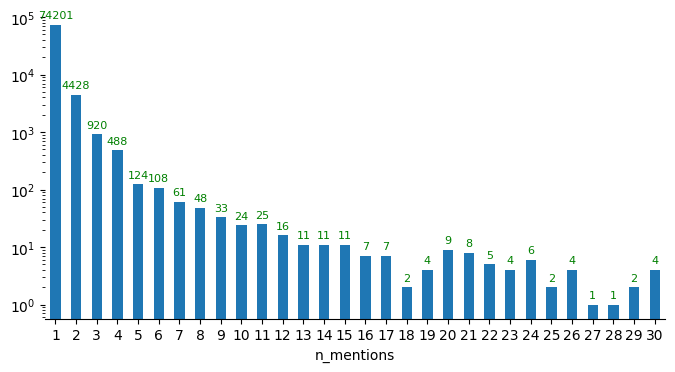

In [11]:
ax = n_mentions.sort_index().head(30).plot.bar(figsize=(8,4), rot=0, logy=True)
ax.bar_label(ax.containers[0], fontsize=8, padding=3, color='green')
sns.despine(left=True)
plt.show()

### ASSERTION $\rightarrow$ RELATION

Next, we extract RELATION data from the ASSERTION table.

In [12]:
rel_key_cols = ['person_key_x','predicate','person_key_y','start_year'] #, 'assertion_id']
RELATION = ASSERTION.groupby(rel_key_cols).assertion_id.apply(lambda x: list(x)).to_frame('asertion_ids')
RELATION['n_assertions'] = RELATION.asertion_ids.apply(len).sort_values()
RELATION.index.names = ['subject_key', 'predicate', 'object_key', 'start_year']
RELATION

,,,,asertion_ids,n_assertions
subject_key,predicate,object_key,start_year,,
1750-b-f-x@john_j_bowcock,enslaved_to,xxxx-x-x-john_j_bowcock,1850,[699c3363-821f-45c9-8118-ffc63b4947c8],1
1750-b-f-x@john_mcgrath,enslaved_to,xxxx-x-x-john_mcgrath,1850,[c9f2b8d9-7bb4-4a4b-b9ab-f71788bd3170],1
1750-b-f-x@william_rothwell,enslaved_to,xxxx-x-x-william_rothwell,1850,[a871ee41-6f70-4458-b866-b7a7f226bd33],1
1750-b-m-x@colvin_cradock,enslaved_to,xxxx-x-x-colvin_cradock,1850,[09a9a39d-2a91-4d68-bde2-c0324cffb953],1
1756-b-f-x@william_g_carr,enslaved_to,xxxx-x-x-william_g_carr,1850,[e3074714-c11a-4579-bf3e-5421d2ef5f1d],1
...,...,...,...,...,...
xxxx-x-x-wm_southall,enslaved_to,xxxx-x-x-wm_southall,1853,[93a5ce48-83b3-4c74-9f94-6f4b151bf58c],1
xxxx-x-x-wm_wood,enslaved_to,xxxx-x-x-wm_wood,1856,[0a87875c-e325-40c1-926f-ed95a0fa0165],1
xxxx-x-x-wm_woods,enslaved_to,xxxx-x-x-wm_woods,1851,[aedfdd9a-0bcd-43e0-9bed-48584c69a543],1


In [13]:
RELATION.n_assertions.value_counts()

n_assertions
1     65141
2       929
3       181
4        56
5        12
6         6
7         3
8         2
11        1
Name: count, dtype: int64

In [14]:
RELATION[RELATION.n_assertions > 1].reset_index().predicate.value_counts()

predicate
enslaved_to    1155
sibling_to        9
mother_to         8
father_to         8
parent_to         4
child_to          4
spouse_to         2
Name: count, dtype: int64

In [15]:
RELATION[RELATION.n_assertions > 1].sort_index()

,,,,asertion_ids,n_assertions
subject_key,predicate,object_key,start_year,,
1770-b-f-x@john_dunham,enslaved_to,xxxx-x-x-john_dunham,1850,"[b466b751-54c2-437b-804d-ee4cad44e193, c60deaa...",2
1775-b-f-x@tucker_coles,enslaved_to,xxxx-x-x-tucker_coles,1850,"[3226bb95-a6e5-4620-99e8-6cbb73a56d68, 238ace0...",2
1775-b-m-x@john_dunham,enslaved_to,xxxx-x-x-john_dunham,1850,"[b1a7c891-fef9-467c-a62c-d0cc0745a5bb, a0f0bd7...",2
1775-b-m-x@thomas_garland,enslaved_to,xxxx-x-x-thomas_garland,1850,"[5ac98ac7-4d21-44c4-bf15-ece0635806d5, eca6d1b...",2
1775-b-m-x@tucker_coles,enslaved_to,xxxx-x-x-tucker_coles,1850,"[bc8386f8-a44d-44a1-a60c-f15612992265, 6938fbc...",3
...,...,...,...,...,...
xxxx-x-m-john_rice,father_to,1867-x-x-joseph_rice,1876,"[535017ea-3383-4304-b63d-d82b76e33309, 604a543...",2
xxxx-x-m-nancy_lucas,father_to,1840-x-x-sybella_tate,1876,"[934fc143-522b-428a-8360-85c7f481b412, bd08240...",2
xxxx-x-m-peter_harris,father_to,1856-b-f-bell_harris,1874,"[f08a9cac-a9e3-425f-a6ca-f6ee5dd691ec, 83fcb73...",2


### Add RELATION counts to PERSON

In [16]:
PERSON['n_relations'] = RELATION.reset_index().subject_key.value_counts()
PERSON.n_relations = PERSON.n_relations.fillna(0)
PERSON.n_relations = PERSON.n_relations.astype(int)
PERSON['n_relations_as_object'] = RELATION.reset_index().object_key.value_counts()
PERSON.n_relations_as_object = PERSON.n_relations_as_object.fillna(0)
PERSON.n_relations_as_object = PERSON.n_relations_as_object.astype(int)

In [30]:
PERSON.value_counts(['n_relations','n_relations_as_object'])\
    .sort_index()\
    .unstack(fill_value=0).T.iloc[:20,:]\
    .style.background_gradient(axis=0, cmap="YlGnBu")

n_relations,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,25,26,29,35,59
n_relations_as_object,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,38160,13643,291,80,31,16,16,11,8,3,5,1,2,5,3,4,3,3,2,4,2,2,2,1,2,1,2,1
1,3161,6593,1758,384,320,234,148,96,55,27,7,3,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,1464,2322,2528,912,253,161,101,58,30,8,4,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,100,489,1248,1022,176,114,61,33,13,7,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,63,354,275,486,295,66,37,11,7,5,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
5,46,254,167,126,343,86,14,8,3,2,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
6,48,161,105,68,44,220,40,3,1,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
7,27,106,63,37,15,16,136,20,2,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
8,35,62,33,11,6,6,12,88,16,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


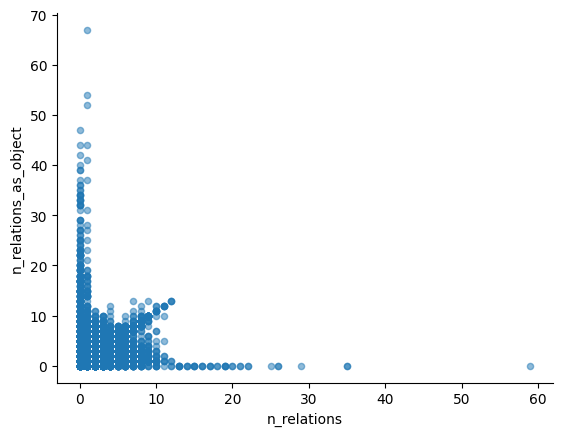

In [18]:
PERSON.sort_values('n_relations', ascending=False).plot.scatter(x='n_relations', y='n_relations_as_object', alpha=.5)
sns.despine()
plt.show()

In [42]:
RELATION.loc['1832-b-m-i_flannagan']

asertion_ids  \
predicate object_key                    start_year                                           
parent_to 1854-b-m-joe_flannagan        1880        [28256fbc-e1b4-45c8-9495-8cd017976bdc]   
          1858-b-f-eliza_flannagan      1880        [1a036bff-72ad-4880-a511-10df47a0438e]   
          1860-b-m-washington_flannagan 1880        [cebbcd06-64f5-4810-af37-f01cf1b1b07b]   
          1862-b-f-margaret_flannagan   1880        [658443e2-7673-48d4-b7a4-52d4e9f4b0a3]   
          1864-b-f-annie_flannagan      1880        [26ef008a-2b49-4539-90a7-d6666052aedb]   
          1868-b-m-james_flannagan      1880        [80ef75ee-2cf7-4879-b1da-3fe0dd415edc]   
          1869-b-f-belle_flannagan      1880        [5336f056-e07a-4ba0-8b1f-326b5d7e3e13]   
          1870-b-m-wm_flannagan         1880        [590f5ca0-4918-41ef-ae11-ed299a2eba07]   
          1872-b-f-mary_flannagan       1880        [52899c15-36b5-4f21-b1c2-6bfae2de8ae0]   
          1875-b-m-chapman_flannagan    1880        [184a34b6-fc3e-452b-bee5-8c078943c0d4]   
          1877-b-f-julia_flannagan      1880        [d87333aa-7993-43b0-a729-6f72e11711c9]   
          1880-b-m-eugene_flannagan     1880        [603cd199-2aa0-49a8-be82-3589be7e5ada]   

                                                    n_assertions  
predicate object_key                    start_year                
parent_to 1854-b-m-joe_flannagan        1880                   1  
          1858-b-f-eliza_flannagan      1880                   1  
          1860-b-m-washington_flannagan 1880                   1  
          1862-b-f-margaret_flannagan   1880                   1  
          1864-b-f-annie_flannagan      1880                   1  
          1868-b-m-james_flannagan      1880                   1  
          1869-b-f-belle_flannagan      1880                   1  
          1870-b-m-wm_flannagan         1880                   1  
          1872-b-f-mary_flannagan       1880                   1  
          1875-b-m-chapman_flannagan    1880                   1  
          1877-b-f-julia_flannagan      1880                   1  
          1880-b-m-eugene_flannagan     1880                   1

In [33]:
PERSON.loc[(PERSON.n_relations > 10) & (PERSON.n_relations_as_object > 10)].index

Index(['1833-w-m-william_hotopp', '1843-w-f-nancy_howard',
       '1838-w-m-wm_j_leake', '1825-b-m-joseph_wars',
       '1840-w-m-william_austin', '1828-w-m-wm_c_gay',
       '1834-w-m-peter_w_fitch', '1832-b-m-i_flannagan'],
      dtype='str', name='person_key')

### Interactive Tools

In [19]:
X = PERSON[(PERSON.n_relations > 2) & (PERSON.n_relations_as_object > 2)]

In [20]:
X.sample().index[0]

'1847-w-f-mary_m_mead'

In [34]:
p = X.sample().index[0]
print(p, ":", sep="")
try:
    relations = RELATION.loc[p].sort_index().reset_index().values
    for rel in relations:
        print("-- ", end="")
        print(rel[0], rel[1], sep="\t")
except KeyError as e:
    print("-- Has no recorded relations.")

1864-w-m-john_w_moon:
-- child_to	1862-w-f-anna_l_moon
-- grandchild_to	1860-w-f-mary_l_moon
-- spouse_to	1865-w-f-fanny_moon


In [35]:
# RELATION

In [41]:
person_auto_widget = widgets.Combobox(
    value=PERSON.sample().index[0],
    options=PERSON.index.to_list(),
    description='Person ID:',
    continuous_update=False
)
@interact(person_id=person_auto_widget)
def view_person(person_id):
    mention_cols = ['source', 'source_year', 'household_id', 'family_id', 'norm_occupation']
    # display(HTML(f"<h3>Person ID: {person_id.replace("_", " ").replace("-", " ").title()}</h3>"))
    try:
        person = PERSON.loc[person_id]
    except KeyError as e:
        display(HTML("<tt>Try again.</tt>"))
        return None
    test_ids = person.mention_ids

    display(HTML("<h3>PERSON</h3>")) 
    display(PERSON.loc[person_id].to_frame().T)
    
    display(HTML("<h3>MENTION</h3>"))
    display(MENTION.loc[test_ids].sort_values('source_year')[mention_cols].T.dropna().T)

    display(HTML("<h3>RELATION</h3>"))
    display(RELATION.query(f"subject_key == '{person_id}'"))

    display(HTML("<h3>ASSERTION</h3>"))
    display(ASSERTION.query(f"person_key_x == '{person_id}'")[['source_year_x','source_year_y']])


interactive(children=(Combobox(value='1859-w-f-alice_carter', continuous_update=False, description='Person ID:…

## Save

In [24]:
MENTION.to_parquet("../data/MENTION.parquet", index=True)
ASSERTION.to_parquet("../data/ASSERTION.parquet", index=True)
PERSON.to_parquet("../data/PERSON.parquet", index=True)
RELATION.to_parquet("../data/RELATION.parquet", index=True)

## Explore

### Distribution of Source Years

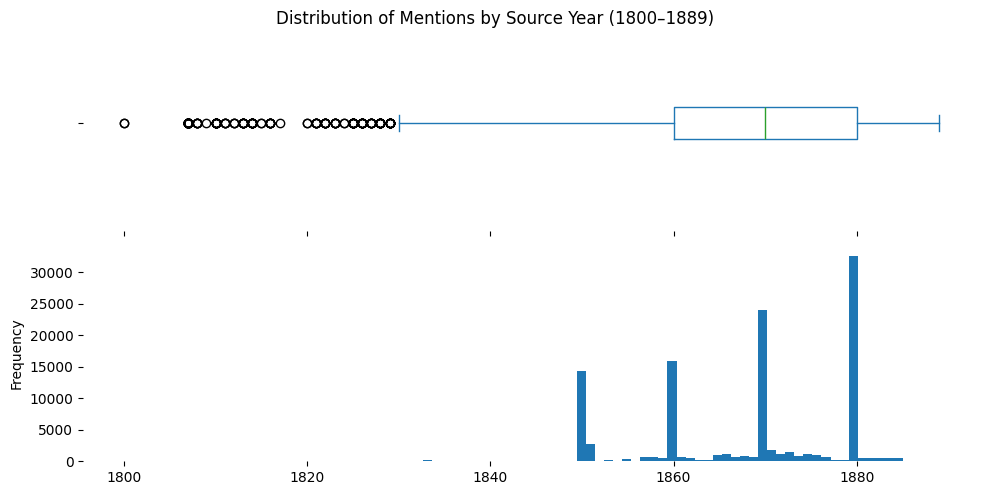

In [25]:
date_range = (MENTION.source_year >= 1800) & (MENTION.source_year < 1890)
X = MENTION[date_range].source_year

fig, axes = plt.subplots(2, 1, sharex=True, figsize=(10,5))

X.plot.box(ax=axes[0], vert=False)
X.plot.hist(ax=axes[1], bins=90)

axes[0].set_yticklabels("")

sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.suptitle("Distribution of Mentions by Source Year (1800–1889)")
plt.show()

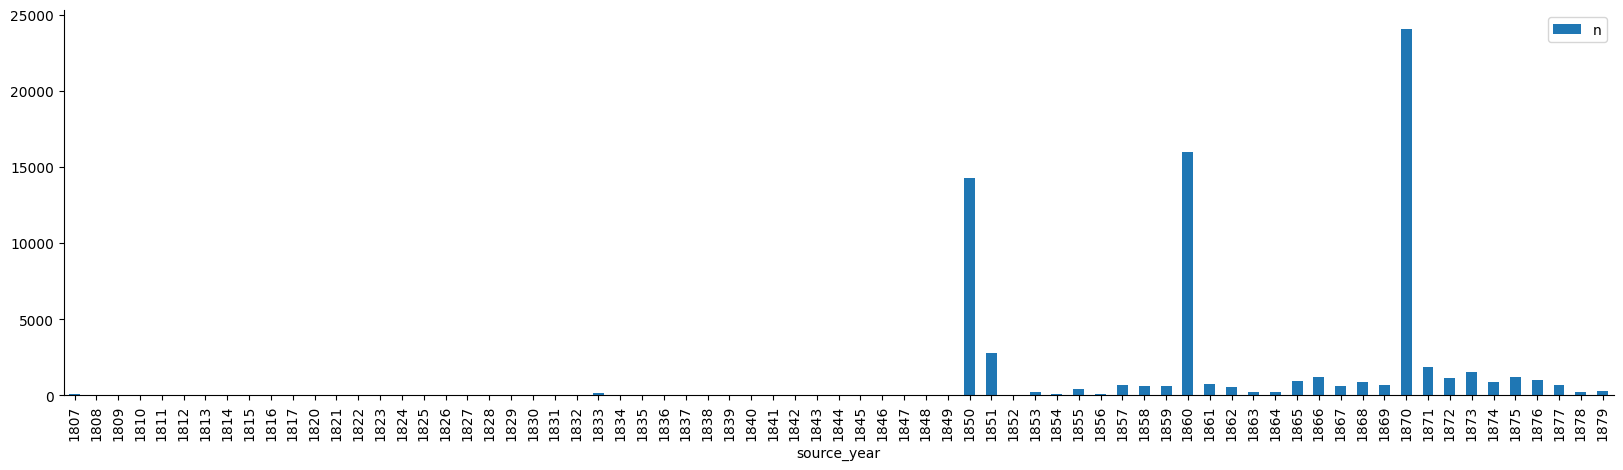

In [26]:
(
    MENTION[(MENTION.source_year > 1800) & (MENTION.source_year < 1880)]
        .value_counts('source_year')
        .to_frame('n')
        .sort_index()
        .plot.bar(figsize=(20,5))
)
sns.despine()

### Distribution of Birth Years

In [27]:
PERSON['birth_year_int'] = PERSON.birth_year.str.replace("XXXX", "0").astype(int)
# PERSON

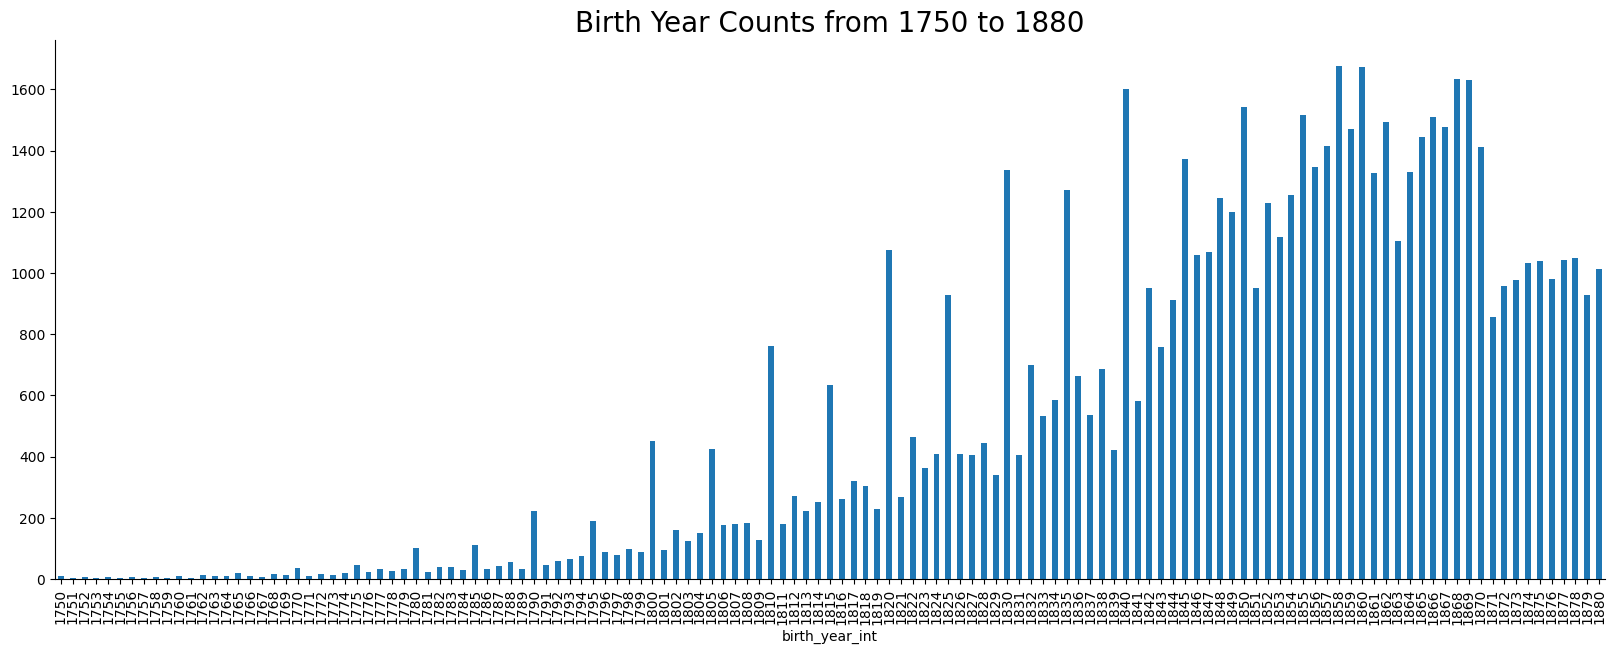

In [28]:
X = PERSON[(PERSON.birth_year_int >= 1750) & (PERSON.birth_year_int < 1881)].birth_year_int.value_counts().sort_index()
X.plot.bar(x='birth_year', y='n', figsize=(20,7))
plt.title("Birth Year Counts from 1750 to 1880", fontsize=20)
sns.despine()
plt.show()

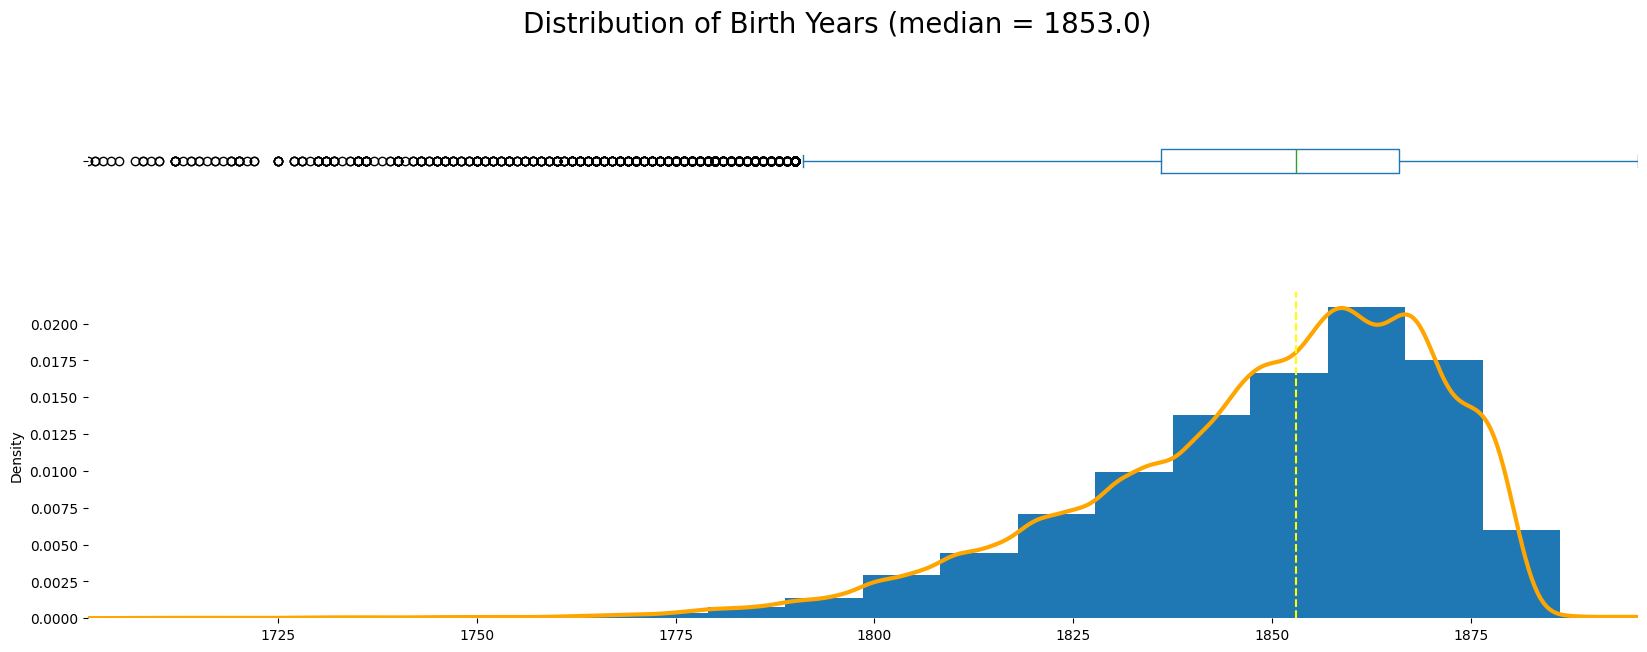

In [29]:
X = PERSON.loc[PERSON.birth_year_int > 1700, 'birth_year_int']

fig, axes = plt.subplots(2, 1, figsize=(20, 7), sharex=True,
    gridspec_kw={'height_ratios': [1, 2]})

X.plot.box(ax=axes[0], vert=False)
X.plot.hist(ax=axes[1], bins=20, density=True)
X.plot.kde(ax=axes[1], color='orange', lw=3)

axes[0].set_yticklabels([])
axes[0].tick_params(axis='x', which='both', bottom=False, labelbottom=False)
axes[1].axvline(X.median(), color='yellow', ls='--')
axes[0].set_xlim(X.min(), X.max())
axes[1].set_xlim(X.min(), X.max())

sns.despine(left=True, bottom=True)
plt.suptitle(rf"Distribution of Birth Years (median = {X.median().round(2)})", fontsize=20)
plt.show()